In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
mnist = fetch_openml('mnist_784',version=1, as_frame=False) #lấy tập dữ liệu mnist chứa các dữ liệu về chữ số từ 0 - 10, dùng as_frame = false để nó tương thích với numpy, mặc định nó là pandas

Shape of mnist:  (70000, 784)
N:  70000
D:  784
Tất cả Y:  ['5' '0' '4' ... '4' '5' '6']
X0:  [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
X0:  [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


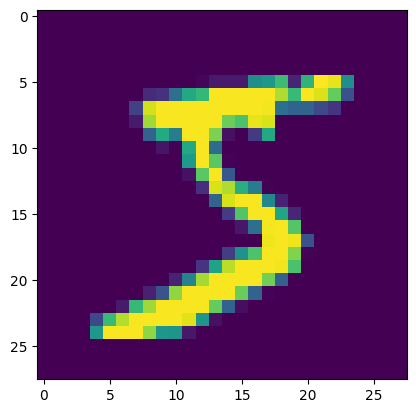

In [ ]:
N,d = mnist.data.shape
print("Shape of mnist: ",mnist.data.shape)
print("N: ",N);
print("D: ",d);
y_all = mnist.target #lấy danh sách các loại chữ từ 0-9
print("Tất cả Y: ",y_all)
x_all = mnist.data
print("X0: ",x_all)
x_0 = x_all[np.where(y_all == '0')[0]] # y_all =='0' trả về một mảng các phần tử là true, false dụa trên dk =='0' và np.where trả về một tuple chứa một array chứa index của các phần tử true của dk trả về, sau đó lấy phần tử đầu tiên trong tuple là một mảng array
x_1 = x_all[np.where(y_all=='1')[0]]
print("X0: ",x_0)
plt.imshow(x_all[0].reshape(28,28)) #chuyển 784 phần tử của array 1d về array 2d 28X28 (image) của phần tử thứ 10 trong x_0

In [ ]:
y_0 = np.zeros(x_0.shape[0]) #tạo ra mảng 2 chiều giá trị 0 với số hàng bằng với số hàng của tập dữ liệu và số cột là 1
y_1 = np.ones(x_1.shape[0]) #tạo ra mảng 2 chiều giá trị 1 với số hàng bằng với số hàng của tập dữ liệu và số cột là 1

In [ ]:
X = np.concatenate((x_0, x_1), axis=0)
Y = np.concatenate((y_0 ,y_1))
print("X: ",X)
print("Y: ",Y)


X:  [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Y:  [0. 0. 0. ... 1. 1. 1.]


In [ ]:
one = np.ones((X.shape[0],1))
X = np.concatenate((X,one),axis=1)
print(X)

[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


In [ ]:
def signmoid(s):
  return 1/(1+np.exp(-s))

In [ ]:
def sgd(x,y,theta_ini, eta=0.05, gamma = 0.9):
  theta_old= theta_ini
  theta_epoch = theta_ini
  v_old = np.zeros_like(theta_ini)
  N = X.shape[0] #lấy số hàng của X

  for it in range(1000):
    mix_id = np.random.permutation(N)
    for i in mix_id:
      xi = X[i,:]
      yi = y[i]
      hi = signmoid(np.dot(xi,theta_old.T))
      gradient_i = (hi - yi)*xi #đạo hàm của J

      v_new = gamma * v_old + eta*gradient_i #tính SGD momatary
      theta_new = theta_old - v_new
      theta_old = theta_new
      v_old = v_new

    if(np.linalg.norm(theta_epoch - theta_old)< 1e-3):
      break;

    theta_epoch = theta_old

  return (theta_epoch, it)

In [ ]:
theta_init = np.random.rand(1, X.shape[1])[0]
(theta,it) = sgd(X,Y,theta_init)
print("Theta=",theta,"Iteration=",it)

<ipython-input-6-144d99a402bb>:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-s))


Theta= [ 6.25490016e-01  3.18814694e-01  4.50810274e-01  4.47675194e-01
  4.36038537e-01  1.79883828e-01  3.82353414e-01  1.16409948e-01
  9.09680725e-02  3.90626506e-01  8.22138925e-01  8.98348420e-01
  6.13251471e-01  8.04880557e-01  8.60797020e-01  7.11275784e-01
  1.29767110e-01  8.39199734e-01  8.47681761e-03  2.69247008e-01
  9.39030281e-01  4.16542403e-01  7.88648323e-01  6.59669022e-01
  1.18477210e-01  2.42765070e-01  7.27597328e-01  3.08078481e-01
  3.50393741e-01  2.46150096e-01  6.91345450e-01  2.31850121e-01
  8.28969076e-01  2.38235185e-01  6.29086210e-01  4.88126415e-01
  8.94260530e-01  6.98818812e-01  3.63539441e-01 -6.30188941e+01
 -1.26250854e+02 -5.15415727e+01  6.23803637e-01  5.27045862e-01
  1.69197019e-01  8.45752159e-01  5.86317935e-01  1.96928854e-01
  5.64922925e-01  1.73773051e-01  2.47754072e-03  5.13584386e-01
  4.33610081e-01  8.14130462e-01  5.04333330e-01  4.65317602e-02
  3.01270779e-01  8.76914021e-01  9.87008462e-02  3.83056837e-01
  6.27094177e-01  

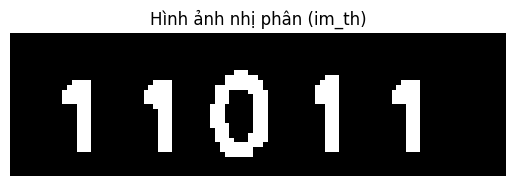

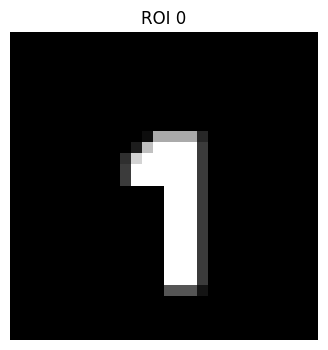

ROI 0 - Kết quả dự đoán: [[1.]]


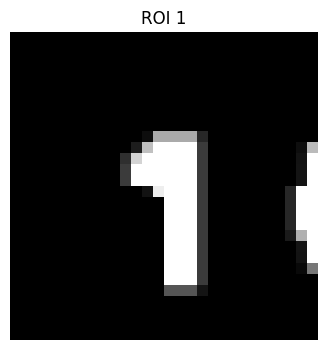

ROI 1 - Kết quả dự đoán: [[1.]]


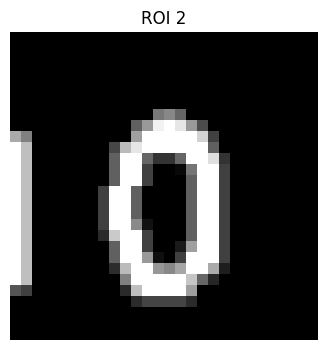

ROI 2 - Kết quả dự đoán: [[0.]]


<ipython-input-6-144d99a402bb>:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-s))


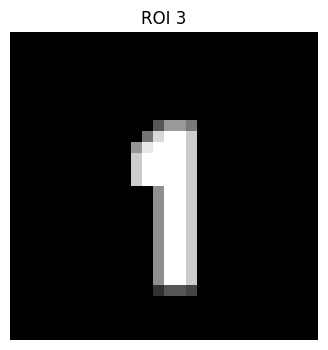

ROI 3 - Kết quả dự đoán: [[1.]]


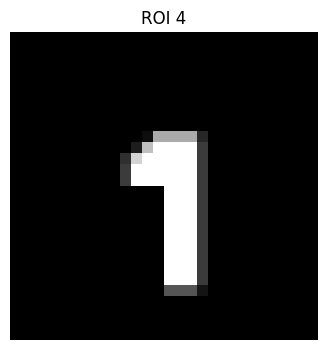

ROI 4 - Kết quả dự đoán: [[1.]]


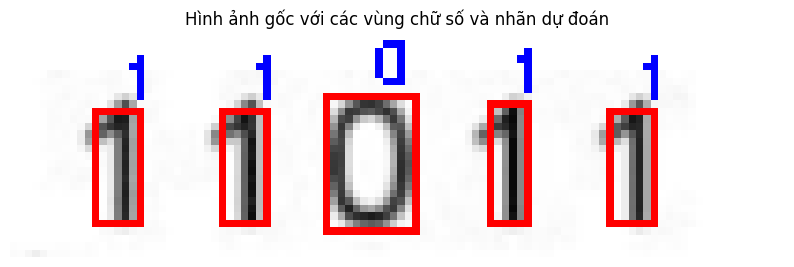

In [ ]:
import cv2
# Tải hình ảnh từ URL
img_path = "/content/test1.png"
img = cv2.imread(img_path)

# Chuyển sang grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Nhị phân hóa
_, im_th = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY_INV)

# Loại bỏ nhiễu
kernel = np.ones((3, 3), np.uint8)
im_th = cv2.morphologyEx(im_th, cv2.MORPH_OPEN, kernel)

# Kiểm tra im_th
plt.imshow(im_th, cmap='gray')
plt.title("Hình ảnh nhị phân (im_th)")
plt.axis('off')
plt.show()

# Tạo cột bias
ones = np.ones((1, 1))

# Tìm contours
ctrs, _ = cv2.findContours(im_th.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rects = [cv2.boundingRect(ctr) for ctr in ctrs]

# Sắp xếp rects theo tọa độ x (từ trái sang phải)
rects.sort(key=lambda x: x[0])

# Danh sách để lưu các roi
rois = []

# Vẽ hình chữ nhật và dự đoán
for i, rect in enumerate(rects):
    cv2.rectangle(img, (rect[0], rect[1]), (rect[0] + rect[2], rect[1] + rect[3]), (0, 0, 255), 1)

    # Đảm bảo tọa độ không vượt quá kích thước hình ảnh
    h, w = im_th.shape
    padding = 10
    y1 = max(rect[1] - padding, 0)
    y2 = min(rect[1] + rect[3] + padding, h)
    x1 = max(rect[0] - padding, 0)
    x2 = min(rect[0] + rect[2] + padding, w)
    roi = im_th[y1:y2, x1:x2]

    # Resize và chuẩn hóa roi
    roi = cv2.resize(roi, (28, 28), interpolation=cv2.INTER_AREA)
    roi = roi / 255.0  # Chuẩn hóa về [0, 1]
    rois.append(roi)

    # Kiểm tra roi
    plt.figure(figsize=(4, 4))
    plt.imshow(roi, cmap='gray')
    plt.title(f"ROI {i}")
    plt.axis('off')
    plt.show()

    # Chuẩn bị roi để dự đoán
    roi = roi.reshape(1, 784)
    roi = np.concatenate((roi, ones), axis=1)
    roi = roi.reshape(1, 785)

    # Dự đoán
    result = signmoid(np.dot(roi, theta.reshape(785, 1)))

    print(f"ROI {i} - Kết quả dự đoán:", result)

    # Ghi nhãn dự đoán lên hình ảnh gốc
    cv2.putText(img, str(int(result[0][0])), ((rect[0]+int(rect[2]/2)), rect[1] -2), cv2.FONT_HERSHEY_SIMPLEX, 0.25, (255, 0, 0), 1)

# Hiển thị hình ảnh gốc
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.title("Hình ảnh gốc với các vùng chữ số và nhãn dự đoán")
plt.axis('off')
plt.show()

